# AIM is to save document into database

#### installed : 
```bash
pip install pandas
```

In [8]:
# from django.db import connection
# from asgiref.sync import sync_to_async

In [1]:
from dotenv import load_dotenv
load_dotenv()
import psycopg2
import os
import sys

In [2]:

# import django

sys.path.append(r'D:\Rushal\VS_code\Python\ProjectIII\backend')
os.chdir(r'D:\Rushal\VS_code\Python\ProjectIII\backend')

# os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'backend.settings')
# django.setup()

# from common.models import Document_Source, InterviewQuestions

In [3]:
base_path = r"ai/documents/question_answers/"
# base_path = r""

In [5]:
all_files = os.listdir(base_path)
all_files
# backend\ai\documents

['hardquestions.xlsx', 'mediumquestions.xlsx', 'simple_questions.xlsx']

In [7]:
all_files[2]

'simple_questions.xlsx'

In [9]:
filepath = base_path + all_files[2]

In [10]:
import pandas as pd
import json

In [11]:
df = pd.read_excel(filepath)

In [13]:
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.width', None)
df.rename(columns={'ideal_answer': 'answer'}, inplace=True)
df.head(3)

,question,role,answer,keywords
0,Tell me about a time you had to learn somethin...,DevOps Engineer,I'm always eager to learn and embrace change a...,"['flexible', 'change']"
1,Describe a time you handled a difficult situat...,Product Manager,"When faced with conflict, I approach it calmly...","['problem', 'disagree']"
2,Where do you see yourself in 5 years?,Data Scientist,My long-term goal is to grow into a senior rol...,"['aspiration', 'dream']"


In [14]:
df.shape

(320, 4)

In [15]:
from ai.utils.embeddings import embed_text_local

In [16]:
em = embed_text_local("thik xau")
em[:3]

[-0.49727994203567505, 0.2624587416648865, -3.3480136394500732]

In [17]:
# fake_df = df[:30]
fake_df = df
# Step 1: Create the column as object dtype
# fake_df['question_embedding'] = None  # Temporary placeholder

# # Step 2: Convert to object dtype (critical!)
# fake_df['question_embedding'] = fake_df['question_embedding'].astype(object)
fake_df.shape

(320, 4)

In [13]:
# # Step 3: Generate and assign embeddings
# for idx, row in fake_df.iterrows():
#     embedding = embed_text_local(row['question'])
#     fake_df.at[idx, 'question_embedding'] = embedding
#     print(f"✅ {idx+1}/{len(fake_df)} done")

## THIS IS HOW U SOLVE USING FROM DB for docker to USING LOCALHOST

In [18]:

# When running from Jupyter on Windows
conn = psycopg2.connect(
    host='localhost',  # ← Change this!
    port=5433,
    database=os.getenv('POSTGRES_DB', 'Vector_test'),
    user=os.getenv('POSTGRES_USER', 'Vector_Test'),
    password=os.getenv('POSTGRES_PASSWORD', 'password')
)
conn.autocommit = True
cur = conn.cursor()

#### port kaa maamla babu bhaiyaaa

In [19]:
cur.execute("SELECT current_database(), current_user, inet_server_addr(), inet_server_port();")
print(cur.fetchone())

('Vector_Database', 'postgres', '172.19.0.2', 5432)


In [29]:
cur.execute("""
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_type = 'BASE TABLE'
AND table_schema NOT IN ('pg_catalog', 'information_schema')
ORDER BY table_schema, table_name;
""")

for schema, table in cur.fetchall():
    print(f"{schema}.{table}")

public.accounts_user
public.accounts_user_groups
public.accounts_user_user_permissions
public.accounts_userprofile
public.auth_group
public.auth_group_permissions
public.auth_permission
public.chats_chatmessage
public.chats_chatsession
public.common_askedquestions
public.common_chatmessage
public.common_document_source
public.common_interviewquestions
public.common_simpletextembedding
public.django_admin_log
public.django_content_type
public.django_migrations
public.django_session


In [30]:
cur.execute("SELECT datname FROM pg_database WHERE datistemplate = false;")
print(cur.fetchall())

[('postgres',), ('Vector_Database',)]


In [20]:
try:
    cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")

    cur.execute("""
        SELECT EXISTS (
            SELECT 1
            FROM pg_extension
            WHERE extname = 'vector'
        );
    """)

    if cur.fetchone()[0]:
        print("✅ pgvector extension is installed and enabled!")
    else:
        print("❌ pgvector extension was NOT found.")

except Exception as e:
    print(f"❌ Error: {e}")

✅ pgvector extension is installed and enabled!


In [32]:
for idx, rows in fake_df.iterrows():
    print(f'idx {idx}, rows : {rows[:10]}...')

idx 0, rows : role                                          Product Manager
question    Tell me about a product you love. How would yo...
keywords    user empathy, prioritization, metrics, trade-offs
answer      I use Spotify daily, and the job it does for m...
Name: 0, dtype: str...
idx 1, rows : role                                          Product Manager
question    How would you improve [common app, e.g. YouTub...
keywords    goal clarification, user segment, prioritized ...
answer      First I'd clarify the goal — are we optimizing...
Name: 1, dtype: str...
idx 2, rows : role                                          Product Manager
question                   Design a product for [X use case].
keywords    clarify user, pain points, prioritize, MVP, su...
answer      I'd start by clarifying who the user is and wh...
Name: 2, dtype: str...
idx 3, rows : role                                          Product Manager
question    How would you prioritize a backlog of 10 featu...
keyword

In [33]:
try:
    cur.execute("""
        CREATE TABLE IF NOT EXISTS interview_test_questions (
            id SERIAL PRIMARY KEY,
            question TEXT NOT NULL,
            role TEXT,
            answer TEXT,
            roles TEXT,
            keywords TEXT,
            question_embedding vector(768)
        );
    """)

    print("✅ Table created successfully!")

except Exception as e:
    print(f"❌ Error creating table: {e}")

✅ Table created successfully!


In [35]:
try:
    for _, row in fake_df.iterrows():

        cur.execute("""
            INSERT INTO interview_test_questions
            (question, role, answer, roles, keywords, question_embedding, answer_embedding)
            VALUES (%s, %s, %s, %s, %s, %s, %s);
        """, (
            row["question"],
            row["role"],
            row["answer"],
            row["keywords"],
            embed_text_local(row["question"]),
            embed_text_local(row['answer'])
        ))

    print(f"✅ Inserted {len(fake_df)} questions!")

except Exception as e:
    print(f"❌ Error inserting data: {e}")

❌ Error inserting data: tuple index out of range


In [36]:
cur.execute("TRUNCATE TABLE interview_test_questions")

In [35]:
def semantic_search(query_embedding, table_name='interview_test_questions', top_k=1):
    # Convert list to string for PostgreSQL
    embedding_str = '[' + ','.join(map(str, query_embedding)) + ']'
    
    # Cosine similarity search
    cur.execute(f"""
        SELECT 
            question,
            answer,
            role,
            1 - (question_embedding <=> %s::vector) AS similarity
        FROM {table_name}
        WHERE question_embedding IS NOT NULL
        ORDER BY question_embedding <=> %s::vector
        LIMIT %s;
    """, (embedding_str, embedding_str, top_k))
    
    return cur.fetchall()


In [34]:
query = embed_text_local("senior")
semantic_search(query)

[("Scenario: The DevOps team has been experiencing intermittent issues with automated test failures in our Selenium Grid setup. As the Scrum Master, you've noticed that these failures mostly occur during critical business hours and have led to delays in deploying new features. Given our HIPAA compliance obligations and tight deadlines, can you walk me through your strategy for triaging this issue? Discuss your approach to identify the root cause, prioritize fixes, coordinate with the DevOps and QA teams, and ensure that such issues don't recur in the future.",
  "Good question — this is the kind of trade-off I've had to navigate before, so let me walk through how I'd handle it. I'd reproduce the issue reliably first, narrow down the root cause with logs and metrics, and resist the urge to patch symptoms, paying close attention to Selenium Grid, HIPAA compliance, intermittent issues, automated test failures since those are the constraints that actually drive the right answer here. Concr

# Lets Do Some Dhaaasu

In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import ollama
import matplotlib.pyplot as plt
import seaborn as sns
import ollama

In [22]:
# ============================================================
# 1. Define Profile Prototypes (6 levels)
# ============================================================
experience_profiles = {
    "none": """
    Entry-level interview question suitable for a candidate with no
    professional work experience. Focuses on basic knowledge, fundamental
    concepts, education, personal projects, learning ability, motivation,
    communication, and theoretical understanding. Does not require
    previous job experience.
    """,
    
    "intern": """
    Internship-level interview question suitable for a student or beginner
    with limited practical industry experience. Focuses on learning,
    academic projects, basic technical skills, willingness to learn,
    teamwork, guidance, and applying knowledge under supervision.
    """,

    "junior": """
    Junior-level interview question suitable for a professional with
    approximately one to two years of experience. Focuses on practical
    skills, basic independent work, implementing solutions, debugging,
    collaboration, learning from senior colleagues, and handling
    moderately challenging tasks.
    """,

    "mid_level": """
    Mid-level interview question suitable for a professional with
    approximately three to five years of experience. Requires independent
    problem solving, ownership of features or projects, solid practical
    expertise, handling complex tasks, making technical decisions,
    collaborating across teams, and improving existing systems.
    """,

    "senior": """
    Senior-level interview question requiring strong technical expertise,
    independent decision making, system design, leadership, mentoring,
    complex problem solving, architecture, ownership, strategic thinking,
    and significant professional experience.
    """,

    "any": """
    General interview question that can be asked to candidates regardless
    of their professional experience level. Focuses on universal skills,
    personality, motivation, communication, work style, adaptability,
    career goals, or general knowledge rather than a specific amount of
    professional experience.
    """
}

In [23]:
# ============================================================
# 2. Embed All Profiles
# ============================================================
def get_embedding(text):
    return ollama.embeddings(model='nomic-embed-text', prompt=text)['embedding']

profile_embeddings = {
    level: get_embedding(text) for level, text in experience_profiles.items()
}
profile_matrix = np.array(list(profile_embeddings.values()))

In [24]:
# ============================================================
# 3. Score Each Row Against All Profiles
# ============================================================
def assign_experience(row_text, profile_matrix, profile_names):
    """Assign experience level based on max cosine similarity."""
    row_embed = get_embedding(row_text)
    similarities = cosine_similarity([row_embed], profile_matrix)[0]  # Shape: (6,)
    
    # Get best match
    best_idx = np.argmax(similarities)
    assigned_level = profile_names[best_idx]
    confidence_score = similarities[best_idx]
    
    return {
        "assigned_level": assigned_level,
        "confidence_score": confidence_score,
        "all_scores": dict(zip(profile_names, similarities))
    }

In [25]:
# ============================================================
# 4. Process Your Dataset
# ============================================================
fake_df
profile_names = list(experience_profiles.keys())

results = []
for _, row in fake_df.iterrows():
    combined_text = f"Question: {row['question']}\nAnswer: {row['answer']}"
    result = assign_experience(combined_text, profile_matrix, profile_names)
    results.append(result)

# Add to dataframe
fake_df['assigned_experience'] = [r['assigned_level'] for r in results]
fake_df['confidence'] = [r['confidence_score'] for r in results]

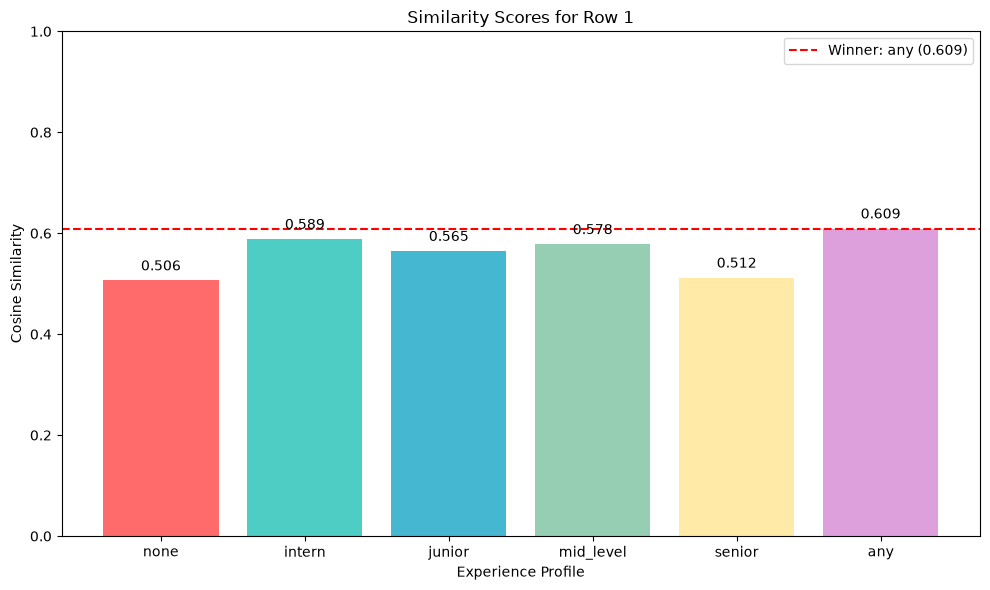

In [26]:
# ============================================================
# 5. Visualization: Similarity Heatmap for a Sample Row
# ============================================================
def plot_similarity_for_row(row_index):
    """Show how this row scored against all 6 profiles."""
    sample = results[row_index]
    levels = profile_names
    scores = [sample['all_scores'][level] for level in levels]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(levels, scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'])
    plt.axhline(y=sample['confidence_score'], color='red', linestyle='--', label=f"Winner: {sample['assigned_level']} ({sample['confidence_score']:.3f})")
    plt.xlabel('Experience Profile')
    plt.ylabel('Cosine Similarity')
    plt.title(f'Similarity Scores for Row {row_index+1}')
    plt.legend()
    plt.ylim(0, 1)
    
    # Add value labels
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.3f}', ha='center')
    
    plt.tight_layout()
    plt.savefig(f'similarity_row_{row_index+1}.png')
    plt.show()

# Plot first row as example
plot_similarity_for_row(0)

In [28]:
# ============================================================
# 6. Overall Distribution Visualization
# ============================================================
def plot_assignment_distribution():
    """Show how many rows assigned to each experience level."""
    ax = fake_df['assigned_experience'].value_counts().plot(kind='bar', color='skyblue')
    ax.set_xlabel('Experience Level')
    ax.set_ylabel('Number of Rows')
    ax.set_title('Distribution of Assigned Experience Levels')
    
    for i, v in enumerate(fake_df['assigned_experience'].value_counts().values):
        plt.text(i, v + 5, str(v), ha='center')
    
    plt.tight_layout()
    plt.savefig('assignment_distribution.png')
    plt.show()

# ============================================================
# 7. Export Results
# ============================================================
fake_df.to_csv('simple_qno_with_experience.csv', index=False)
print("✅ Results exported to 'med_qno_with_experience.csv'")

✅ Results exported to 'med_qno_with_experience.csv'


In [25]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
from pprint import pprint

In [26]:

for i,row in fake_df.iterrows():
    if row.assigned_experience.lower() == "senior":
        print(row.question,row.answer)
        break
    print("count",i)

count 0
Suppose we're planning to develop a new AI-powered anomaly detection system for our drone fleets, aiming to increase flight safety and efficiency. As the Engineering Manager, you've been tasked with selecting an appropriate machine learning framework and associated tooling to handle real-time data processing at scale. Given the complexities of our drones' telemetry data and regulatory requirements like privacy and latency, could you discuss your rationale for choosing between TensorFlow or PyTorch, and explain which supporting tools (e.g., Dask or Horovod) and architectural patterns (e.g., event-driven or microservices) would best suit our needs? That's a real situation, and I'd approach it methodically rather than reacting immediately. I'd evaluate the options against our concrete constraints rather than hype, running a small proof of concept before committing, paying close attention to AI, anomaly detection, TensorFlow, PyTorch since those are the constraints that actually dr

In [ ]:
# fake_df.head(3)


In [29]:
assigned_df = pd.read_csv("simple_qno_with_experience.csv")

In [31]:
assigned_df[assigned_df['assigned_experience'] == 'none'].shape[0]

0

In [32]:
assigned_df['assigned_experience'].value_counts()

assigned_experience
any          176
mid_level    144
Name: count, dtype: int64

assigned_experience
mid_level    16884
senior        3547
intern          10
any              3
Name: count, dtype: int64


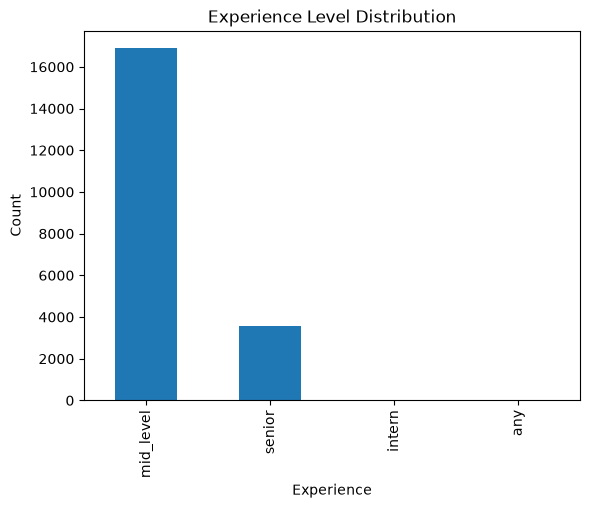

In [50]:
# Visualize all experience levels
print(assigned_df['assigned_experience'].value_counts())
assigned_df['assigned_experience'].value_counts().plot(kind='bar')
plt.title('Experience Level Distribution')
plt.xlabel('Experience')
plt.ylabel('Count')
plt.show()

In [ ]:
unique_roles = df['role'].unique()
print(unique_roles)

with open('roles.json','w') as f:
    json.dumps(unique_roles)

<StringArray>
[                            'Network Engineer',
                          'Engineering Manager',
          'Penetration Tester / Ethical Hacker',
                   'Scrum Master / Agile Coach',
                          'Solutions Architect',
                            'Platform Engineer',
                 'Database Administrator (DBA)',
        'Blockchain / Smart Contract Developer',
                               'MLOps Engineer',
                     'Computer Vision Engineer',
                               'Game Developer',
                               'Data Scientist',
                   'Sales / Solutions Engineer',
                    'Technical Product Manager',
            'Security Operations (SOC) Analyst',
                               'UX/UI Designer',
           'Business Intelligence (BI) Analyst',
                                'Data Engineer',
                                 'NLP Engineer',
                     'Test Automation Engineer',
      

In [13]:
unique_roles

<StringArray>
[                            'Network Engineer',
                          'Engineering Manager',
          'Penetration Tester / Ethical Hacker',
                   'Scrum Master / Agile Coach',
                          'Solutions Architect',
                            'Platform Engineer',
                 'Database Administrator (DBA)',
        'Blockchain / Smart Contract Developer',
                               'MLOps Engineer',
                     'Computer Vision Engineer',
                               'Game Developer',
                               'Data Scientist',
                   'Sales / Solutions Engineer',
                    'Technical Product Manager',
            'Security Operations (SOC) Analyst',
                               'UX/UI Designer',
           'Business Intelligence (BI) Analyst',
                                'Data Engineer',
                                 'NLP Engineer',
                     'Test Automation Engineer',
      

In [18]:
with open('roles.json','w') as f:
    json.dump(unique_roles.tolist(), f)